<a href="https://colab.research.google.com/github/Btec-19825/ML-Assignment-2026/blob/main/Titanic_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Load dataset
ds = pd.read_csv('train.csv')
ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Fill missing values (assign directly to avoid FutureWarning)
ds['Age'] = ds['Age'].fillna(ds['Age'].median())
ds['Embarked'] = ds['Embarked'].fillna(ds['Embarked'].mode()[0])
ds['Fare'] = ds['Fare'].fillna(ds['Fare'].median())

# Feature Engineering: Family Size and IsAlone
ds['FamilySize'] = ds['SibSp'] + ds['Parch']
ds['IsAlone'] = 0
ds.loc[ds['FamilySize'] == 0, 'IsAlone'] = 1

# Extract Title from Name (fix invalid escape)
ds['Title'] = ds['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
ds['Title'] = ds['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major',
                                   'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
ds['Title'] = ds['Title'].replace('Mlle', 'Miss')
ds['Title'] = ds['Title'].replace('Ms', 'Miss')
ds['Title'] = ds['Title'].replace('Mme', 'Mrs')

# Label Encoding
le = LabelEncoder()
ds['Sex'] = le.fit_transform(ds['Sex'])
ds['Embarked'] = le.fit_transform(ds['Embarked'])
ds['Title'] = le.fit_transform(ds['Title'])

In [3]:
# Select input features and target label
X = ds[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']]
y = ds['Survived']

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [5]:
# Logistic Regression Performance
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest Performance
print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


=== Random Forest ===
Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



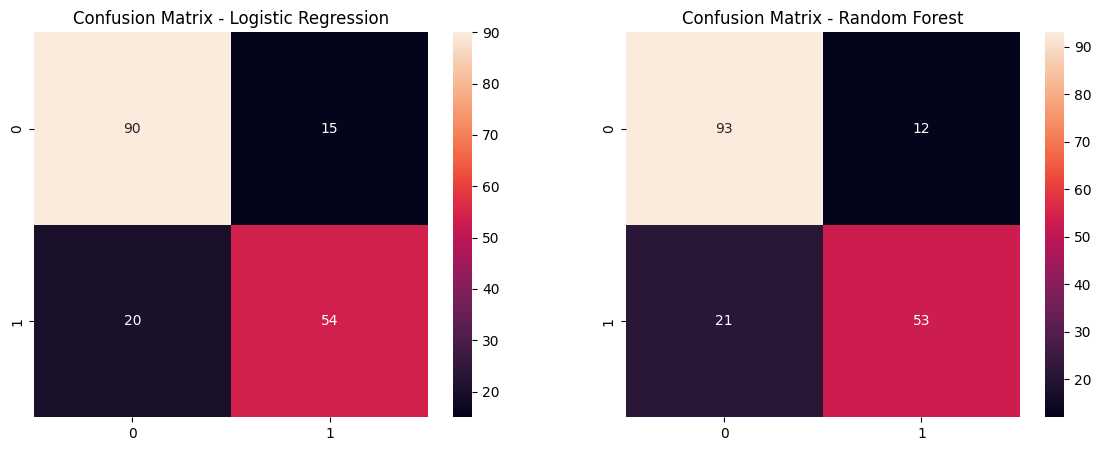

In [6]:
# Plot Confusion Matrices
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axs[0])
axs[0].set_title('Confusion Matrix - Logistic Regression')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axs[1])
axs[1].set_title('Confusion Matrix - Random Forest')

plt.show()

In [7]:
# 5-Fold Cross Validation
scores_lr = cross_val_score(lr, X, y, cv=5)
scores_rf = cross_val_score(rf, X, y, cv=5)

print("5-Fold Cross Validation Accuracy (Logistic Regression):", scores_lr.mean())
print("5-Fold Cross Validation Accuracy (Random Forest):", scores_rf.mean())

5-Fold Cross Validation Accuracy (Logistic Regression): 0.7980101688531793
5-Fold Cross Validation Accuracy (Random Forest): 0.8260184545853996


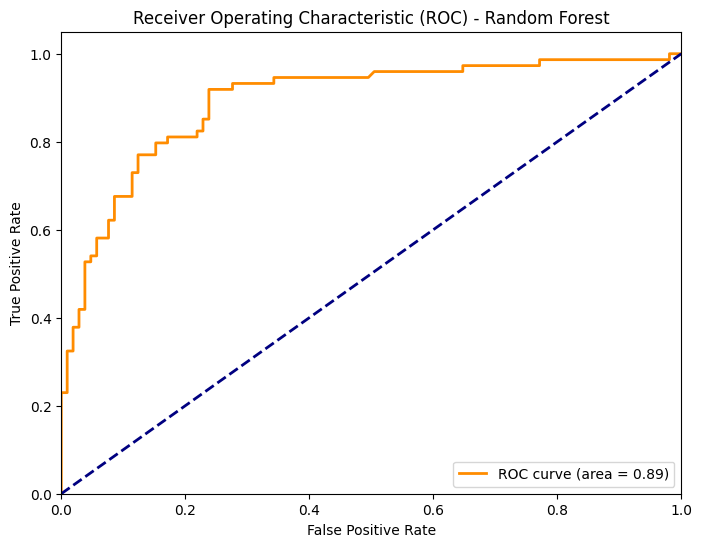

In [8]:
# Plot ROC Curve
y_pred_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest')
plt.legend(loc="lower right")
plt.show()